# Early Warning for Student Attrition
## An Explainable and Fair Machine Learning Approach

### 01 — Dataset Assessment

This notebook assesses the source dataset before exploratory analysis, feature engineering, or model development.

The purpose is to answer five questions:

1. What does the dataset contain?
2. Is the data structurally complete and usable?
3. Which variables are truly categorical, numerical, or coded categories?
4. When does each feature become available in the student journey?
5. Which variables require special attention for leakage, fairness, or modeling?

This notebook intentionally avoids predictive modeling.


## 1. Dataset Source and Justification

**Dataset:** Predict Students' Dropout and Academic Success  
**Repository:** UCI Machine Learning Repository  
**Dataset ID:** 697  
**DOI:** 10.24432/C5MC89  
**License:** Creative Commons Attribution 4.0 International (CC BY 4.0)  
**Original task:** Three-class classification — `Dropout`, `Enrolled`, `Graduate`

According to UCI, the dataset contains **4,424 student records and 36 predictive features**. Each record represents one student. The source combines information available at enrollment with academic performance at the end of the first and second semesters.

Official source:  
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

The dataset was created to support earlier identification of students at risk of academic dropout and failure. This makes it suitable for the capstone's early-warning use case, but the timing of each feature must be handled carefully.


## 2. Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)


In [3]:
!git clone https://github.com/rayvaril/student-dropout-capstone.git

Cloning into 'student-dropout-capstone'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 83 (delta 33), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 717.05 KiB | 6.23 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [4]:
%cd /content/student-dropout-capstone/notebooks

/content/student-dropout-capstone/notebooks


## 3. Load the Raw Dataset

The dataset should remain unchanged in the `data/` folder. Any transformations will later be saved separately as processed data.

The loader below checks common repository and Google Colab locations.


In [5]:
candidate_paths = [
    Path("../data/data.csv"),
    Path("data/data.csv"),
    Path("/content/data.csv")
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "data.csv was not found. Place the raw UCI file in the repository's data folder "
        "or upload it to the current Colab session."
    )

# sep=None lets pandas infer whether the file is comma- or semicolon-delimited.
df = pd.read_csv(data_path, sep=None, engine="python")

print(f"Loaded dataset from: {data_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Loaded dataset from: ../data/data.csv
Shape: 4,424 rows × 37 columns


## 4. Structural Validation

Before interpreting the data, confirm that the downloaded file matches the expected UCI structure.


In [6]:
EXPECTED_ROWS = 4424
EXPECTED_FEATURES = 36
EXPECTED_TOTAL_COLUMNS = EXPECTED_FEATURES + 1  # predictors + target

validation = pd.DataFrame({
    "check": [
        "Expected row count",
        "Expected total columns",
        "Target column present"
    ],
    "expected": [
        EXPECTED_ROWS,
        EXPECTED_TOTAL_COLUMNS,
        True
    ],
    "observed": [
        len(df),
        df.shape[1],
        "Target" in df.columns
    ]
})

validation


,check,expected,observed
0,Expected row count,4424,4424
1,Expected total columns,37,37
2,Target column present,True,True


A mismatch does not automatically mean the dataset is invalid, but it should be investigated before continuing.


## 5. Preview the Records


In [7]:
df.head()


,﻿Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 6. Variable Inventory

The column names already reveal an important aspect of this dataset: some information is available at enrollment, while other information becomes available only after Semester 1 or Semester 2.

That timing matters because the capstone is framed as an **early-warning** problem.


In [8]:
column_inventory = pd.DataFrame({
    "column_number": range(1, len(df.columns) + 1),
    "feature": df.columns,
    "storage_dtype": [str(df[col].dtype) for col in df.columns],
    "unique_values": [df[col].nunique(dropna=False) for col in df.columns]
})

column_inventory


,column_number,feature,storage_dtype,unique_values
0,1,﻿Marital status,int64,6
1,2,Application mode,int64,18
2,3,Application order,int64,8
3,4,Course,int64,17
4,5,Daytime/evening attendance\t,int64,2
5,6,Previous qualification,int64,17
6,7,Previous qualification (grade),float64,101
7,8,Nacionality,int64,21
8,9,Mother's qualification,int64,29
9,10,Father's qualification,int64,34


## 7. Storage Type vs. Semantic Type

A key risk in this dataset is treating coded categories as continuous numbers.

For example, variables such as `Marital status`, `Course`, and `Application mode` are stored as integers, but the numbers are **labels**, not quantities. A course code of 9500 is not "more" than a course code of 33.

The semantic-type classification below separates coded categorical variables from genuinely numerical variables.


In [9]:
def clean_feature_name(name):
    return (
        str(name)
        .replace("\ufeff", "")   # remove hidden BOM character
        .strip()
        .replace("\t", " ")
    )

categorical_features = {
    "marital status",
    "application mode",
    "course",
    "daytime/evening attendance",
    "previous qualification",
    "nacionality",
    "mother's qualification",
    "father's qualification",
    "mother's occupation",
    "father's occupation",
    "displaced",
    "educational special needs",
    "debtor",
    "tuition fees up to date",
    "gender",
    "scholarship holder",
    "international"
}

ordinal_features = {
    "application order"
}

def infer_semantic_type(column):
    normalized = clean_feature_name(column).casefold()

    if normalized == "target":
        return "Target"

    if normalized in categorical_features:
        return "Categorical / coded"

    if normalized in ordinal_features:
        return "Ordinal"

    return "Numerical"

semantic_types = pd.DataFrame({
    "feature": df.columns,
    "clean_feature": [clean_feature_name(col) for col in df.columns],
    "storage_dtype": [str(df[col].dtype) for col in df.columns],
    "semantic_type": [infer_semantic_type(col) for col in df.columns],
    "unique_values": [df[col].nunique(dropna=False) for col in df.columns]
})

semantic_types

,feature,clean_feature,storage_dtype,semantic_type,unique_values
0,﻿Marital status,Marital status,int64,Categorical / coded,6
1,Application mode,Application mode,int64,Categorical / coded,18
2,Application order,Application order,int64,Ordinal,8
3,Course,Course,int64,Categorical / coded,17
4,Daytime/evening attendance\t,Daytime/evening attendance,int64,Categorical / coded,2
5,Previous qualification,Previous qualification,int64,Categorical / coded,17
6,Previous qualification (grade),Previous qualification (grade),float64,Numerical,101
7,Nacionality,Nacionality,int64,Categorical / coded,21
8,Mother's qualification,Mother's qualification,int64,Categorical / coded,29
9,Father's qualification,Father's qualification,int64,Categorical / coded,34


This classification is a modeling decision and should be checked against the official UCI variable documentation before preprocessing.


## 8. Missing Values

UCI reports that the released dataset contains no missing values. We still verify that locally rather than assuming the downloaded file is identical.


In [10]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_summary


,missing_count,missing_pct
﻿Marital status,0,0.0
Application mode,0,0.0
Application order,0,0.0
Course,0,0.0
Daytime/evening attendance\t,0,0.0
Previous qualification,0,0.0
Previous qualification (grade),0,0.0
Nacionality,0,0.0
Mother's qualification,0,0.0
Father's qualification,0,0.0


In [11]:
total_missing = int(df.isna().sum().sum())
print(f"Total missing cells: {total_missing:,}")


Total missing cells: 0


### Assessment

No missing values were detected across the dataset. Therefore, no imputation strategy is required at this stage. Any preprocessing decisions can focus on feature encoding, scaling, class balance, and leakage rather than missing-data treatment.

## 9. Duplicate Records

Exact duplicate rows may distort distributions and model evaluation.


In [12]:
duplicate_count = int(df.duplicated().sum())
duplicate_pct = duplicate_count / len(df) * 100

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_pct:.2f}%")


Duplicate rows: 0
Duplicate percentage: 0.00%


### Assessment

No exact duplicate records were detected. The dataset does not require deduplication before exploratory analysis or modeling.

## 10. Basic Data-Quality Checks

This section looks for structural issues that could affect later analysis:

- constant features
- near-constant features
- unusually high-cardinality variables
- unexpected target labels

These checks flag issues for investigation; they do not automatically justify dropping a variable.


In [13]:
quality_checks = []

for col in df.columns:
    nunique = df[col].nunique(dropna=False)
    most_common_share = df[col].value_counts(
        normalize=True,
        dropna=False
    ).iloc[0]

    semantic_type = infer_semantic_type(col)

    quality_checks.append({
        "feature": clean_feature_name(col),
        "semantic_type": semantic_type,
        "unique_values": nunique,
        "constant": nunique == 1,
        "near_constant_95pct": most_common_share >= 0.95,
        "high_cardinality_categorical": (
            semantic_type == "Categorical / coded"
            and nunique > 50
        )
    })

quality_summary = pd.DataFrame(quality_checks)

quality_summary


,feature,semantic_type,unique_values,constant,near_constant_95pct,high_cardinality_categorical
0,Marital status,Categorical / coded,6,False,False,False
1,Application mode,Categorical / coded,18,False,False,False
2,Application order,Ordinal,8,False,False,False
3,Course,Categorical / coded,17,False,False,False
4,Daytime/evening attendance,Categorical / coded,2,False,False,False
5,Previous qualification,Categorical / coded,17,False,False,False
6,Previous qualification (grade),Numerical,101,False,False,False
7,Nacionality,Categorical / coded,21,False,True,False
8,Mother's qualification,Categorical / coded,29,False,False,False
9,Father's qualification,Categorical / coded,34,False,False,False


### Assessment

No constant features were detected.

Three variables — `Nacionality`, `Educational special needs`, and `International` — are highly imbalanced, with one category representing at least 95% of observations. These features will be retained for now but reviewed during exploratory analysis because their limited representation may affect modeling and subgroup analysis.

High numbers of unique values among continuous variables such as admission and semester grades are expected and are not treated as categorical high-cardinality issues.

No variables are removed at this stage.

In [14]:
expected_targets = {"Dropout", "Enrolled", "Graduate"}

if "Target" in df.columns:
    observed_targets = set(df["Target"].dropna().unique())
    unexpected_targets = observed_targets - expected_targets

    print("Observed target labels:", sorted(observed_targets))
    print("Unexpected target labels:", sorted(unexpected_targets) if unexpected_targets else "None")


Observed target labels: ['Dropout', 'Enrolled', 'Graduate']
Unexpected target labels: None


### Assessment

The target variable contains only the three expected outcome classes: `Dropout`, `Enrolled`, and `Graduate`. No unexpected labels were detected, so no target-label cleaning is required at this stage.

## 11. Numerical Range Review

This is an initial range check, not full exploratory analysis.

The goal is to identify variables that may contain unusually large, small, or otherwise suspicious values that should be investigated in the EDA stage.


In [15]:
numeric_columns = [
    col for col in df.columns
    if infer_semantic_type(col) == "Numerical"
]

range_review = df[numeric_columns].describe().T[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

range_review


,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Admission grade,4424.0,126.978119,14.482001,95.00,117.90,126.100000,134.800000,190.000000
Age at enrollment,4424.0,23.265145,7.587816,17.00,19.00,20.000000,25.000000,70.000000
Curricular units 1st sem (credited),4424.0,0.709991,2.360507,0.00,0.00,0.000000,0.000000,20.000000
Curricular units 1st sem (enrolled),4424.0,6.270570,2.480178,0.00,5.00,6.000000,7.000000,26.000000
Curricular units 1st sem (evaluations),4424.0,8.299051,4.179106,0.00,6.00,8.000000,10.000000,45.000000
Curricular units 1st sem (approved),4424.0,4.706600,3.094238,0.00,3.00,5.000000,6.000000,26.000000
Curricular units 1st sem (grade),4424.0,10.640822,4.843663,0.00,11.00,12.285714,13.400000,18.875000
Curricular units 1st sem (without evaluations),4424.0,0.137658,0.690880,0.00,0.00,0.000000,0.000000,12.000000
Curricular units 2nd sem (credited),4424.0,0.541817,1.918546,0.00,0.00,0.000000,0.000000,19.000000


### Assessment

The numerical ranges do not reveal any immediately impossible values. Several observations will require closer examination during exploratory analysis rather than automatic removal.

`Age at enrollment` ranges from 17 to 70, indicating that the dataset includes both traditional and older students. Older observations will be retained and their distribution examined further.

Admission and previous-qualification grades fall within plausible ranges based on the source dataset. Semester academic variables contain several zero values, including grades, enrolled units, evaluations, and approved units. These zeros may represent meaningful academic outcomes rather than missing data and will be investigated alongside related semester variables before preprocessing decisions are made.

Some curricular-unit counts show relatively high maximum values compared with their medians. These observations will be visualized during EDA to determine whether they represent valid but uncommon academic patterns.

Negative inflation and GDP values are plausible macroeconomic observations and are not treated as data errors.

No numerical observations are removed at this stage.

Do not automatically remove extreme values. Some may be valid observations, particularly for age, economic indicators, or academic performance.


## 12. Original Target Distribution

The source dataset uses a three-class outcome:

- `Dropout`
- `Enrolled`
- `Graduate`

At this stage, the original labels are preserved. The binary transformation for the main capstone model will be performed later and documented explicitly.


In [16]:
target_counts = df["Target"].value_counts()
target_pct = df["Target"].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
})

target_summary


,count,percentage
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


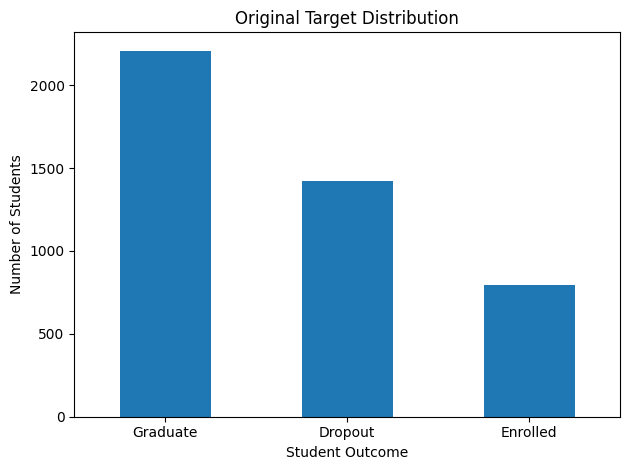

In [17]:
ax = target_counts.plot(kind="bar")
ax.set_title("Original Target Distribution")
ax.set_xlabel("Student Outcome")
ax.set_ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Assessment

The original target distribution is moderately imbalanced.

- `Graduate`: 2,209 students (49.93%)
- `Dropout`: 1,421 students (32.12%)
- `Enrolled`: 794 students (17.95%)

For the planned binary classification task, `Enrolled` and `Graduate` will later be grouped into `Non-Dropout`, resulting in an approximate 32:68 class split.

This level of imbalance is meaningful but not extreme. Model evaluation will therefore emphasize recall, precision, F1-score, ROC-AUC, PR-AUC, and confusion matrices rather than accuracy alone.

No resampling strategy is selected at this stage. Class weighting, threshold tuning, or resampling will only be considered after baseline model performance is evaluated.

### Class-Balance Check

The source documentation notes class imbalance. We quantify it here because it will influence the choice of evaluation metrics later.


In [18]:
majority_class = target_counts.idxmax()
minority_class = target_counts.idxmin()
imbalance_ratio = target_counts.max() / target_counts.min()

print(f"Majority class: {majority_class} ({target_counts.max():,})")
print(f"Minority class: {minority_class} ({target_counts.min():,})")
print(f"Majority-to-minority ratio: {imbalance_ratio:.2f}:1")


Majority class: Graduate (2,209)
Minority class: Enrolled (794)
Majority-to-minority ratio: 2.78:1


### Class Balance Assessment

The original three-class target has a majority-to-minority ratio of 2.78:1, with `Graduate` as the largest class and `Enrolled` as the smallest.

This confirms moderate class imbalance. The imbalance is significant enough to influence evaluation strategy but not severe enough to justify resampling automatically.

For the primary binary classification task, the class distribution will be reassessed after `Enrolled` and `Graduate` are combined into `Non-Dropout`.

## 13. Feature Availability by Student Journey Stage

This is one of the most important assessments in the project.

A model can achieve strong performance while still failing the intended use case if it relies on information that becomes available too late.

The feature timing below is based on the structure described by UCI and the variable names. It should be reviewed before the modeling stage.


In [19]:
def infer_availability_stage(column):
    lower = column.lower()

    if column == "Target":
        return "Outcome"

    if "1st sem" in lower:
        return "Semester 1"

    if "2nd sem" in lower:
        return "Semester 2"

    if column in {"Unemployment rate", "Inflation rate", "GDP"}:
        return "External context"

    return "Enrollment"

availability = pd.DataFrame({
    "feature": df.columns,
    "availability_stage": [infer_availability_stage(col) for col in df.columns]
})

availability["availability_stage"].value_counts()


,count
availability_stage,
Enrollment,21
Semester 1,6
Semester 2,6
External context,3
Outcome,1


In [20]:
print(df.shape)
print(clean_feature_name(" Marital status "))
print(infer_availability_stage("Curricular units 1st sem (grade)"))

(4424, 37)
Marital status
Semester 1


### Assessment

All 37 variables have been assigned to a stage in the student journey:

- 21 enrollment-stage variables
- 6 first-semester variables
- 6 second-semester variables
- 3 external-context variables
- 1 outcome variable

This staging supports the project's early-warning design.

The enrollment-stage model will prioritize information available before meaningful academic performance is observed. A second model will add first-semester academic information to measure how much predictive performance improves when later information becomes available.

Second-semester variables will be excluded from the primary early-warning models because they reduce the available intervention lead time.

External economic variables may be available at both prediction stages and will be evaluated as contextual predictors rather than student-level academic information.

In [21]:
availability


,feature,availability_stage
0,﻿Marital status,Enrollment
1,Application mode,Enrollment
2,Application order,Enrollment
3,Course,Enrollment
4,Daytime/evening attendance\t,Enrollment
5,Previous qualification,Enrollment
6,Previous qualification (grade),Enrollment
7,Nacionality,Enrollment
8,Mother's qualification,Enrollment
9,Father's qualification,Enrollment


### Assessment

The feature-timing review supports the planned early-warning framework.

Most student background, application, admission, and demographic variables are available at or near enrollment. First- and second-semester academic variables are clearly separated, allowing the project to compare an enrollment-stage model with a first-semester model.

Second-semester variables will remain excluded from the primary early-warning models because using them would substantially reduce intervention lead time.

`Debtor` and `Tuition fees up to date` will be verified against the official dataset documentation before modeling to confirm that their recorded values would realistically be available at the intended prediction point.

The three macroeconomic variables are treated as external contextual information and may be included in both early-warning stages if they are known at the prediction date.

### Early-Warning Modeling Implication

The planned models will use different information windows:

**Enrollment-stage model**
- enrollment variables
- demographic / socioeconomic variables
- external context variables

**First-semester model**
- all eligible enrollment-stage variables
- first-semester academic variables

**Excluded from the primary early-warning models**
- second-semester academic variables
- the target outcome

This design allows the project to test the trade-off between **earlier intervention** and **greater predictive information**.


## 14. Leakage and Governance Review

The table below adds preliminary flags for features that deserve special handling.

A governance flag does **not** automatically mean a variable must be removed. It means its role should be justified.


In [22]:
fairness_candidates = {
    "Gender": "Primary fairness candidate",
    "Age at enrollment": "Secondary fairness candidate",
    "Scholarship holder": "Socioeconomic subgroup analysis",
    "Debtor": "Socioeconomic subgroup analysis",
    "Tuition fees up to date": "Socioeconomic subgroup analysis",
    "Educational special needs": "Sensitive subgroup — limited representation",
    "International": "Representation check — highly imbalanced"
}

def model_eligibility(column):
    clean_col = clean_feature_name(column)
    stage = infer_availability_stage(column)

    if stage == "Outcome":
        return False, False, "Exclude — target"

    if stage == "Semester 2":
        return False, False, "Exclude from primary early-warning models"

    if stage == "Semester 1":
        return False, True, "Available only after Semester 1"

    if clean_col in {"Debtor", "Tuition fees up to date"}:
        return True, True, "Verify timing in source documentation"

    return True, True, "No obvious timing concern"

governance_rows = []

for col in df.columns:
    clean_col = clean_feature_name(col)
    enroll_ok, sem1_ok, timing_note = model_eligibility(col)

    governance_rows.append({
        "feature": clean_col,
        "availability_stage": infer_availability_stage(col),
        "eligible_enrollment_model": enroll_ok,
        "eligible_sem1_model": sem1_ok,
        "fairness_relevance": fairness_candidates.get(clean_col, ""),
        "timing_review": timing_note
    })

governance_review = pd.DataFrame(governance_rows)

governance_review


,feature,availability_stage,eligible_enrollment_model,eligible_sem1_model,fairness_relevance,timing_review
0,Marital status,Enrollment,True,True,,No obvious timing concern
1,Application mode,Enrollment,True,True,,No obvious timing concern
2,Application order,Enrollment,True,True,,No obvious timing concern
3,Course,Enrollment,True,True,,No obvious timing concern
4,Daytime/evening attendance,Enrollment,True,True,,No obvious timing concern
5,Previous qualification,Enrollment,True,True,,No obvious timing concern
6,Previous qualification (grade),Enrollment,True,True,,No obvious timing concern
7,Nacionality,Enrollment,True,True,,No obvious timing concern
8,Mother's qualification,Enrollment,True,True,,No obvious timing concern
9,Father's qualification,Enrollment,True,True,,No obvious timing concern


In [23]:
print("clean_feature_name:", callable(clean_feature_name))
print("infer_semantic_type:", callable(infer_semantic_type))
print("infer_availability_stage:", callable(infer_availability_stage))
print("model_eligibility:", callable(model_eligibility))
print("fairness_candidates:", isinstance(fairness_candidates, dict))

clean_feature_name: True
infer_semantic_type: True
infer_availability_stage: True
model_eligibility: True
fairness_candidates: True


## 15. Working Data Dictionary

AIM requires a clear data dictionary. This notebook creates the working structure, while the official UCI definitions and code meanings should be retained as the authoritative source.

The dictionary distinguishes:

- how the variable is stored
- what the variable actually means statistically
- when it becomes available
- whether it has fairness or leakage implications


In [31]:
data_dictionary_rows = []

for col in df.columns:
    clean_col = clean_feature_name(col)
    enroll_ok, sem1_ok, timing_note = model_eligibility(col)

    data_dictionary_rows.append({
        "feature": clean_col,
        "storage_dtype": str(df[col].dtype),
        "semantic_type": infer_semantic_type(col),
        "unique_values": df[col].nunique(dropna=False),
        "missing_values": df[col].isna().sum(),
        "availability_stage": infer_availability_stage(col),
        "eligible_enrollment_model": enroll_ok,
        "eligible_sem1_model": sem1_ok,
        "fairness_relevance": fairness_candidates.get(clean_col, ""),
        "timing_review": timing_note,
        "official_definition_or_codes": "",
        "modeling_decision": ""
    })

data_dictionary = pd.DataFrame(data_dictionary_rows)

data_dictionary

# Match cleaned feature names back to the original dataframe columns
column_lookup = {
    clean_feature_name(col): col
    for col in df.columns
}

def format_value(value):
    if isinstance(value, float):
        if value.is_integer():
            return str(int(value))
        return f"{value:.2f}".rstrip("0").rstrip(".")
    return str(value)

def summarize_values(feature, semantic_type):
    original_col = column_lookup.get(feature)

    if original_col is None:
        return "Not matched"

    series = df[original_col]

    if semantic_type in ["Numerical", "Ordinal"]:
        return (
            f"{format_value(series.min())} to "
            f"{format_value(series.max())}"
        )

    values = sorted(series.dropna().unique().tolist())

    if len(values) <= 20:
        return ", ".join(format_value(v) for v in values)

    return f"{len(values)} observed categories"


data_dictionary["observed_range_or_values"] = data_dictionary.apply(
    lambda row: summarize_values(
        row["feature"],
        row["semantic_type"]
    ),
    axis=1
)

data_dictionary[
    [
        "feature",
        "storage_dtype",
        "semantic_type",
        "unique_values",
        "missing_values",
        "observed_range_or_values",
        "availability_stage",
        "official_definition_or_codes"
    ]
]

,feature,storage_dtype,semantic_type,unique_values,missing_values,observed_range_or_values,availability_stage,official_definition_or_codes
0,Marital status,int64,Categorical / coded,6,0,"1, 2, 3, 4, 5, 6",Enrollment,
1,Application mode,int64,Categorical / coded,18,0,"1, 2, 5, 7, 10, 15, 16, 17, 18, 26, 27, 39, 42, 43, 44, 51, 53, 57",Enrollment,
2,Application order,int64,Ordinal,8,0,0 to 9,Enrollment,
3,Course,int64,Categorical / coded,17,0,"33, 171, 8014, 9003, 9070, 9085, 9119, 9130, 9147, 9238, 9254, 9500, 9556, 9670, 9773, 9853, 9991",Enrollment,
4,Daytime/evening attendance,int64,Categorical / coded,2,0,"0, 1",Enrollment,
5,Previous qualification,int64,Categorical / coded,17,0,"1, 2, 3, 4, 5, 6, 9, 10, 12, 14, 15, 19, 38, 39, 40, 42, 43",Enrollment,
6,Previous qualification (grade),float64,Numerical,101,0,95 to 190,Enrollment,
7,Nacionality,int64,Categorical / coded,21,0,21 observed categories,Enrollment,
8,Mother's qualification,int64,Categorical / coded,29,0,29 observed categories,Enrollment,
9,Father's qualification,int64,Categorical / coded,34,0,34 observed categories,Enrollment,


In [25]:
!pip -q install ucimlrepo

In [26]:
from ucimlrepo import fetch_ucirepo

uci_dataset = fetch_ucirepo(id=697)
uci_variables = uci_dataset.variables.copy()

uci_variables.head()

,name,role,type,demographic,description,units,missing_values
0,Marital Status,Feature,Integer,Marital Status,1 – single 2 – married 3 – widower 4 – divorced 5 – facto union 6 – legally separated,None,no
1,Application mode,Feature,Integer,None,1 - 1st phase - general contingent 2 - Ordinance No. 612/93 5 - 1st phase - special contingent (Azores Island) 7 - H...,None,no
2,Application order,Feature,Integer,None,Application order (between 0 - first choice; and 9 last choice),None,no
3,Course,Feature,Integer,None,33 - Biofuel Production Technologies 171 - Animation and Multimedia Design 8014 - Social Service (evening attendance...,None,no
4,Daytime/evening attendance,Feature,Integer,None,1 – daytime 0 - evening,None,no


In [32]:
def normalize_name(name):
    return (
        str(name)
        .replace("\ufeff", "")
        .replace("\t", " ")
        .strip()
        .casefold()
    )

# Create normalized names for matching
data_dictionary["match_name"] = data_dictionary["feature"].apply(normalize_name)
uci_variables["match_name"] = uci_variables["name"].apply(normalize_name)

# Keep only the metadata fields we need
uci_lookup = uci_variables[
    ["match_name", "description"]
].copy()

# Merge official UCI descriptions into our dictionary
data_dictionary = data_dictionary.merge(
    uci_lookup,
    on="match_name",
    how="left"
)

# Move UCI description into our intended column
data_dictionary["official_definition_or_codes"] = data_dictionary["description"]

# Remove temporary helper columns
data_dictionary = data_dictionary.drop(
    columns=["match_name", "description"]
)

data_dictionary

,feature,storage_dtype,semantic_type,unique_values,missing_values,availability_stage,eligible_enrollment_model,eligible_sem1_model,fairness_relevance,timing_review,official_definition_or_codes,modeling_decision,observed_range_or_values
0,Marital status,int64,Categorical / coded,6,0,Enrollment,True,True,,No obvious timing concern,1 – single 2 – married 3 – widower 4 – divorced 5 – facto union 6 – legally separated,,"1, 2, 3, 4, 5, 6"
1,Application mode,int64,Categorical / coded,18,0,Enrollment,True,True,,No obvious timing concern,1 - 1st phase - general contingent 2 - Ordinance No. 612/93 5 - 1st phase - special contingent (Azores Island) 7 - H...,,"1, 2, 5, 7, 10, 15, 16, 17, 18, 26, 27, 39, 42, 43, 44, 51, 53, 57"
2,Application order,int64,Ordinal,8,0,Enrollment,True,True,,No obvious timing concern,Application order (between 0 - first choice; and 9 last choice),,0 to 9
3,Course,int64,Categorical / coded,17,0,Enrollment,True,True,,No obvious timing concern,33 - Biofuel Production Technologies 171 - Animation and Multimedia Design 8014 - Social Service (evening attendance...,,"33, 171, 8014, 9003, 9070, 9085, 9119, 9130, 9147, 9238, 9254, 9500, 9556, 9670, 9773, 9853, 9991"
4,Daytime/evening attendance,int64,Categorical / coded,2,0,Enrollment,True,True,,No obvious timing concern,1 – daytime 0 - evening,,"0, 1"
5,Previous qualification,int64,Categorical / coded,17,0,Enrollment,True,True,,No obvious timing concern,1 - Secondary education 2 - Higher education - bachelor's degree 3 - Higher education - degree 4 - Higher education ...,,"1, 2, 3, 4, 5, 6, 9, 10, 12, 14, 15, 19, 38, 39, 40, 42, 43"
6,Previous qualification (grade),float64,Numerical,101,0,Enrollment,True,True,,No obvious timing concern,Grade of previous qualification (between 0 and 200),,95 to 190
7,Nacionality,int64,Categorical / coded,21,0,Enrollment,True,True,,No obvious timing concern,1 - Portuguese; 2 - German; 6 - Spanish; 11 - Italian; 13 - Dutch; 14 - English; 17 - Lithuanian; 21 - Angolan; 22 -...,,21 observed categories
8,Mother's qualification,int64,Categorical / coded,29,0,Enrollment,True,True,,No obvious timing concern,1 - Secondary Education - 12th Year of Schooling or Eq. 2 - Higher Education - Bachelor's Degree 3 - Higher Educatio...,,29 observed categories
9,Father's qualification,int64,Categorical / coded,34,0,Enrollment,True,True,,No obvious timing concern,1 - Secondary Education - 12th Year of Schooling or Eq. 2 - Higher Education - Bachelor's Degree 3 - Higher Educatio...,,34 observed categories


In [28]:
unmatched = data_dictionary[
    data_dictionary["official_definition_or_codes"].isna()
][["feature"]]

unmatched

,feature


In [29]:
def assign_modeling_decision(row):
    stage = row["availability_stage"]
    fairness = row["fairness_relevance"]
    timing = row["timing_review"]

    if stage == "Outcome":
        return "Outcome only — exclude from predictors"

    if stage == "Semester 2":
        return "Exclude from primary early-warning models"

    if stage == "Semester 1":
        return "Use only in Semester 1 model"

    if timing == "Verify timing in source documentation":
        return "Candidate feature — verify timing before use"

    if fairness:
        return "Candidate feature — retain with governance/fairness review"

    return "Candidate for Enrollment and Semester 1 models"


data_dictionary["modeling_decision"] = data_dictionary.apply(
    assign_modeling_decision,
    axis=1
)

data_dictionary

,feature,storage_dtype,semantic_type,unique_values,missing_values,availability_stage,eligible_enrollment_model,eligible_sem1_model,fairness_relevance,timing_review,official_definition_or_codes,modeling_decision,observed_range_or_values
0,Marital status,int64,Categorical / coded,6,0,Enrollment,True,True,,No obvious timing concern,1 – single 2 – married 3 – widower 4 – divorced 5 – facto union 6 – legally separated,Candidate for Enrollment and Semester 1 models,None
1,Application mode,int64,Categorical / coded,18,0,Enrollment,True,True,,No obvious timing concern,1 - 1st phase - general contingent 2 - Ordinance No. 612/93 5 - 1st phase - special contingent (Azores Island) 7 - H...,Candidate for Enrollment and Semester 1 models,"1, 2, 5, 7, 10, 15, 16, 17, 18, 26, 27, 39, 42, 43, 44, 51, 53, 57"
2,Application order,int64,Ordinal,8,0,Enrollment,True,True,,No obvious timing concern,Application order (between 0 - first choice; and 9 last choice),Candidate for Enrollment and Semester 1 models,0 to 9
3,Course,int64,Categorical / coded,17,0,Enrollment,True,True,,No obvious timing concern,33 - Biofuel Production Technologies 171 - Animation and Multimedia Design 8014 - Social Service (evening attendance...,Candidate for Enrollment and Semester 1 models,"33, 171, 8014, 9003, 9070, 9085, 9119, 9130, 9147, 9238, 9254, 9500, 9556, 9670, 9773, 9853, 9991"
4,Daytime/evening attendance,int64,Categorical / coded,2,0,Enrollment,True,True,,No obvious timing concern,1 – daytime 0 - evening,Candidate for Enrollment and Semester 1 models,None
5,Previous qualification,int64,Categorical / coded,17,0,Enrollment,True,True,,No obvious timing concern,1 - Secondary education 2 - Higher education - bachelor's degree 3 - Higher education - degree 4 - Higher education ...,Candidate for Enrollment and Semester 1 models,"1, 2, 3, 4, 5, 6, 9, 10, 12, 14, 15, 19, 38, 39, 40, 42, 43"
6,Previous qualification (grade),float64,Numerical,101,0,Enrollment,True,True,,No obvious timing concern,Grade of previous qualification (between 0 and 200),Candidate for Enrollment and Semester 1 models,95.0 to 190.0
7,Nacionality,int64,Categorical / coded,21,0,Enrollment,True,True,,No obvious timing concern,1 - Portuguese; 2 - German; 6 - Spanish; 11 - Italian; 13 - Dutch; 14 - English; 17 - Lithuanian; 21 - Angolan; 22 -...,Candidate for Enrollment and Semester 1 models,21 observed categories
8,Mother's qualification,int64,Categorical / coded,29,0,Enrollment,True,True,,No obvious timing concern,1 - Secondary Education - 12th Year of Schooling or Eq. 2 - Higher Education - Bachelor's Degree 3 - Higher Educatio...,Candidate for Enrollment and Semester 1 models,29 observed categories
9,Father's qualification,int64,Categorical / coded,34,0,Enrollment,True,True,,No obvious timing concern,1 - Secondary Education - 12th Year of Schooling or Eq. 2 - Higher Education - Bachelor's Degree 3 - Higher Educatio...,Candidate for Enrollment and Semester 1 models,34 observed categories


In [35]:
timing_pending = ["Debtor", "Tuition fees up to date"]

data_dictionary.loc[
    data_dictionary["feature"].isin(timing_pending),
    ["eligible_enrollment_model", "eligible_sem1_model"]
] = False

data_dictionary.loc[
    data_dictionary["feature"].isin(timing_pending),
    "modeling_decision"
] = "Exclude pending timing verification"

data_dictionary[
    data_dictionary["feature"].isin(["Debtor", "Tuition fees up to date"])
][
    [
        "feature",
        "eligible_enrollment_model",
        "eligible_sem1_model",
        "modeling_decision"
    ]
]

,feature,eligible_enrollment_model,eligible_sem1_model,modeling_decision
15,Debtor,False,False,Exclude pending timing verification
16,Tuition fees up to date,False,False,Exclude pending timing verification


### Data Dictionary Note

The data dictionary was completed using the official UCI metadata.

Several variables are stored as numbers but actually represent categories, so their meanings were taken from the source documentation rather than interpreted as numerical values.

Examples include `Course`, `Marital status`, and `Application mode`.

The dictionary also notes when each feature becomes available and whether it can be used in the enrollment-stage or first-semester model.

## 16. Initial Dataset Assessment

### Dataset Integrity

The dataset matches the expected UCI structure:

- 4,424 student records
- 37 columns: 36 predictors and 1 target
- 0 missing values
- 0 duplicate rows
- no constant features

Three variables are highly imbalanced: `Nacionality`, `Educational special needs`, and `International`. I will keep them for now and review them more closely during EDA.

### Target Structure

The original target has three classes:

- `Graduate`: 2,209 (49.93%)
- `Dropout`: 1,421 (32.12%)
- `Enrolled`: 794 (17.95%)

The majority-to-minority ratio is 2.78:1, so there is moderate class imbalance.

For the main modeling task, I plan to convert the target into:

- `1` = Dropout
- `0` = Non-Dropout (`Graduate` + `Enrolled`)

This will give an approximate 32:68 split. Because of this, I will not rely on accuracy alone when evaluating the models.

### Feature Timing

The features are grouped based on when they become available:

- 21 enrollment-stage features
- 6 Semester 1 features
- 6 Semester 2 features
- 3 external-context features
- 1 outcome variable

This allows the project to compare two early-warning points:

1. **Enrollment-stage model** — uses information available at or near enrollment.
2. **First-semester model** — adds Semester 1 academic information.

Semester 2 variables will be excluded from the primary early-warning models because they become available too late for the intended use case.

### Initial Modeling Implications

Several variables are stored as integers but are actually categorical codes, including `Course`, `Application mode`, `Marital status`, and parental qualification and occupation variables. These will need appropriate categorical treatment later.

`Gender` and `Age at enrollment` will be the main variables considered for fairness evaluation. Scholarship, debtor, and tuition-status variables may also be used for socioeconomic subgroup analysis.

`Debtor` and `Tuition fees up to date` still need to be checked against the source documentation to confirm that they would realistically be available at the enrollment-stage prediction point.

No features are permanently removed at this stage.

### Key Dataset Risks

The main issues to carry into the next stage are:

- possible timing leakage if later-semester variables are used too early
- moderate class imbalance
- limited representation in some demographic groups
- zero values in several academic variables that may represent real outcomes rather than missing data
- limited generalizability because the dataset comes from a specific higher-education setting

Overall, the dataset is suitable for the proposed early-warning analysis and can proceed to exploratory data analysis.

## 17. Decisions Carried Forward

Based on the dataset assessment, the following decisions will guide the next stages of the project:

1. The original three-class target will be converted into a binary outcome:
   - `1` = Dropout
   - `0` = Non-Dropout (`Graduate` + `Enrolled`)

2. Two prediction stages will be evaluated:
   - Enrollment-stage model
   - First-semester model

3. Semester 2 variables will be excluded from the primary early-warning models.

4. Coded categorical variables will be treated as categorical features rather than continuous numerical variables.

5. `Gender` and `Age at enrollment` will be the main variables considered for fairness evaluation.

6. `Scholarship holder`, `Debtor`, and `Tuition fees up to date` may be used for socioeconomic subgroup analysis.

7. `Debtor` and `Tuition fees up to date` will be checked further to confirm that they are available at the intended enrollment-stage prediction point.

8. No resampling strategy will be applied before baseline modeling. Class weighting or threshold adjustment will only be considered if needed after model evaluation.

9. No features are permanently removed at this stage.

The next step is exploratory data analysis to understand which variables and patterns appear most strongly related to student dropout.

### **Dataset Assessment Summary**

The dataset contains 4,424 student records, 36 predictors, and one target variable.

- No missing values were found.
- No duplicate records were found.
- The target contains three valid outcomes: Dropout, Enrolled, and Graduate.
- Numerical ranges were reviewed for unusual or implausible values.
- Zero values in academic variables were retained because they can represent meaningful student outcomes rather than missing data.
- Features were grouped according to when they become available: enrollment, Semester 1, Semester 2, and external context.
- All variables were matched to the official UCI metadata.
- The data dictionary includes feature type, observed range or values, availability stage, and official definitions or codes.

More detailed distributions and relationships with dropout are explored in `02_exploratory_analysis.ipynb`.